In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/netflix-data-cult26/movies.csv
/kaggle/input/datasets/sahilhussain2410/netflix-data-cult26/ratings_full.parquet


# Dataset Loading

In [5]:
from sklearn.model_selection import train_test_split
import gc
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
ratings_df=pd.read_parquet("/kaggle/input/datasets/sahilhussain2410/netflix-data-cult26/ratings_full.parquet")

In [7]:
movies=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/netflix-data-cult26/movies.csv')

In [8]:
display(ratings_df.head())
ratings_df.shape

,UserID,MovieID,Rating,Date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


(100480507, 4)

In [9]:
print("Ratings :", len(ratings_df))
print("Users   :", ratings_df["UserID"].nunique())
print("Movies  :", ratings_df["MovieID"].nunique())

print()
print("Date Range")

print(ratings_df["Date"].min())
print(ratings_df["Date"].max())

Ratings : 100480507
Users   : 480189
Movies  : 17770

Date Range
1999-11-11 00:00:00
2005-12-31 00:00:00


In [10]:
user_counts = ratings_df.groupby(
    "UserID"
).size()

user_counts.describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
)

count    480189.000000
mean        209.251997
std         302.339155
min           1.000000
25%          39.000000
50%          96.000000
75%         259.000000
90%         541.000000
95%         779.000000
99%        1390.000000
max       17653.000000
dtype: float64

In [11]:
print(movies.shape)

print(
    movies["MovieID"].nunique()
)
print(movies.columns)

(17770, 3)
17770
Index(['MovieID', 'Year', 'Title'], dtype='object')


In [12]:
ratings_df["MovieID"].nunique()

movies["MovieID"].nunique()

set(
    ratings_df["MovieID"].unique()
) - set(
    movies["MovieID"].unique()
)

set()

In [13]:
print(movies.shape)
movies.info()

(17770, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MovieID  17770 non-null  int64  
 1   Year     17763 non-null  float64
 2   Title    17770 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 416.6+ KB


# EDA

###  User Activity Analysis

In [14]:
# compute user statistics
user_counts = ratings_df.groupby(
    "UserID"
).size()

user_counts.describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    480189.000000
mean        209.251997
std         302.339155
min           1.000000
25%          39.000000
50%          96.000000
75%         259.000000
90%         541.000000
95%         779.000000
99%        1390.000000
max       17653.000000
dtype: float64

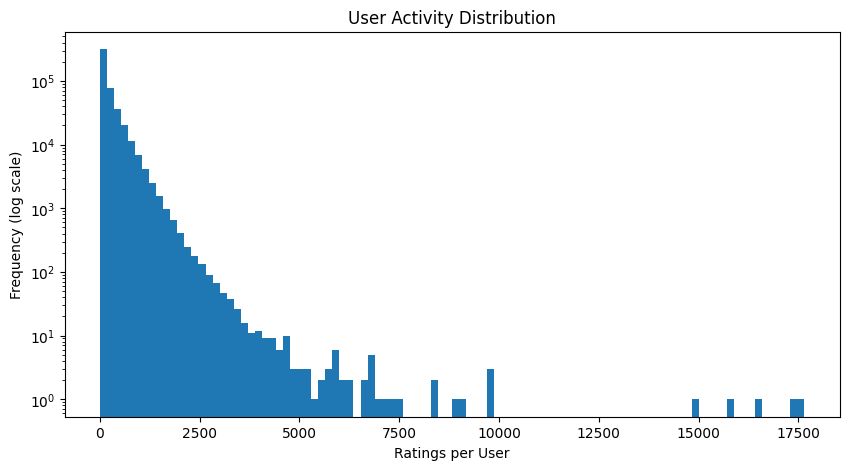

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    user_counts,
    bins=100,
    log=True
)

plt.xlabel("Ratings per User")
plt.ylabel("Frequency (log scale)")
plt.title("User Activity Distribution")
plt.savefig(
    "user_activity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
print(
    "Max ratings by a user:",
    user_counts.max()
)

print(
    "Users with >1000 ratings:",
    (user_counts > 1000).sum()
)

print(
    "Users with >500 ratings:",
    (user_counts > 500).sum()
)

print(
    "Users with <20 ratings:",
    (user_counts < 20).sum()
)

Max ratings by a user: 17653
Users with >1000 ratings: 13100
Users with >500 ratings: 54238
Users with <20 ratings: 50605


### Movie Popularity Analysis

In [17]:
movie_counts = ratings_df.groupby(
    "MovieID"
).size()

movie_counts.describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count     17770.000000
mean       5654.502364
std       16909.673269
min           3.000000
25%         192.000000
50%         561.000000
75%        2667.750000
90%       12303.800000
95%       29199.600000
99%       97128.430000
max      232944.000000
dtype: float64

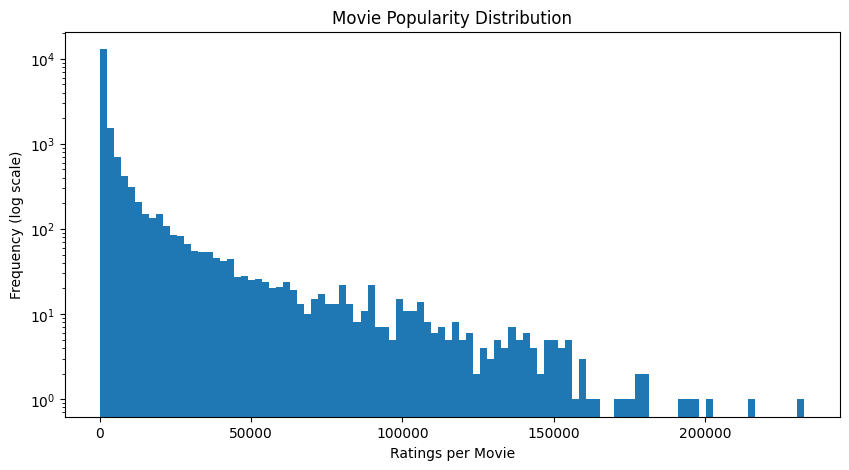

In [243]:
plt.figure(figsize=(10,5))

plt.hist(
    movie_counts,
    bins=100,
    log=True
)

plt.xlabel("Ratings per Movie")
plt.ylabel("Frequency (log scale)")
plt.title("Movie Popularity Distribution")
plt.savefig(
    "movie_popularity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [19]:
# most rated movie
top_movies = (
    ratings_df["MovieID"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_movies.columns = [
    "MovieID",
    "Rating_Count"
]

top_movies = top_movies.merge(
    movies,
    on="MovieID",
    how="left"
)

top_movies[
    ["MovieID","Title","Rating_Count"]
]

,MovieID,Title,Rating_Count
0,5317,Miss Congeniality,232944
1,15124,Independence Day,216596
2,14313,The Patriot,200832
3,15205,The Day After Tomorrow,196397
4,1905,Pirates of the Caribbean: The Curse of the Bla...,193941
5,6287,Pretty Woman,193295
6,11283,Forrest Gump,181508
7,16377,The Green Mile,181426
8,16242,Con Air,178068
9,12470,Twister,177556


### Rating Distribution

In [20]:
rating_dist = (
    ratings_df["Rating"]
    .value_counts()
    .sort_index()
)

rating_dist

Rating
1     4617990
2    10132080
3    28811247
4    33750958
5    23168232
Name: count, dtype: int64

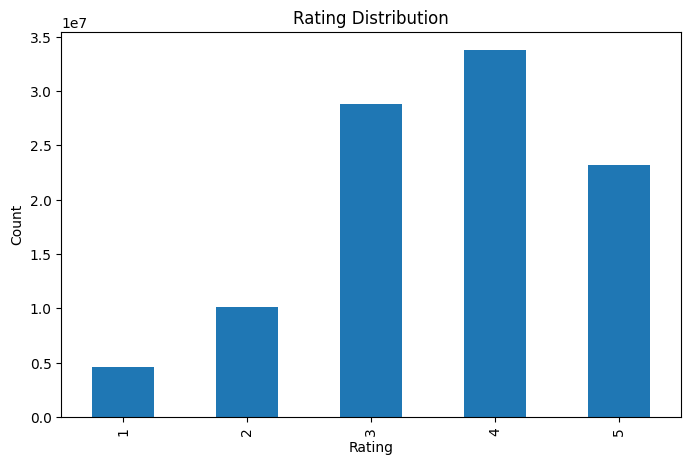

In [244]:
plt.figure(figsize=(8,5))

rating_dist.plot(
    kind="bar"
)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.savefig(
    "ratin_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [22]:
# average rating
ratings_df["Rating"].describe()

count    1.004805e+08
mean     3.604290e+00
std      1.085219e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64

### temporal Analysis

In [23]:
# rating count over month for each year
ratings_df["YearMonth"] = (
    ratings_df["Date"]
    .dt.to_period("M")
)

monthly_ratings = (
    ratings_df.groupby(
        "YearMonth"
    )
    .size()
)

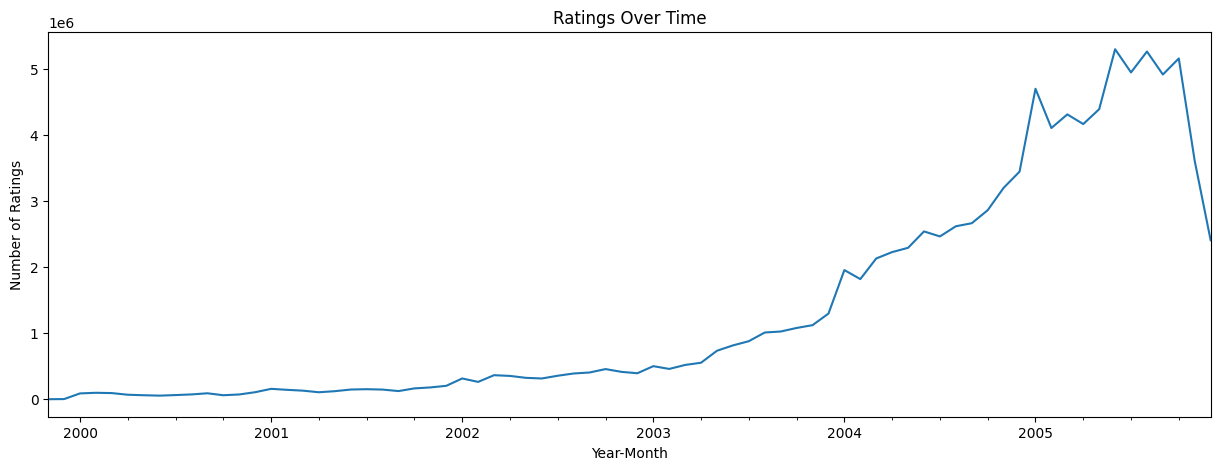

In [245]:
plt.figure(figsize=(15,5))

monthly_ratings.plot()

plt.title(
    "Ratings Over Time"
)

plt.xlabel(
    "Year-Month"
)

plt.ylabel(
    "Number of Ratings"
)
plt.savefig(
    "ratings_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# average rating over time
monthly_avg = (
    ratings_df.groupby(
        "YearMonth"
    )["Rating"]
    .mean()
)

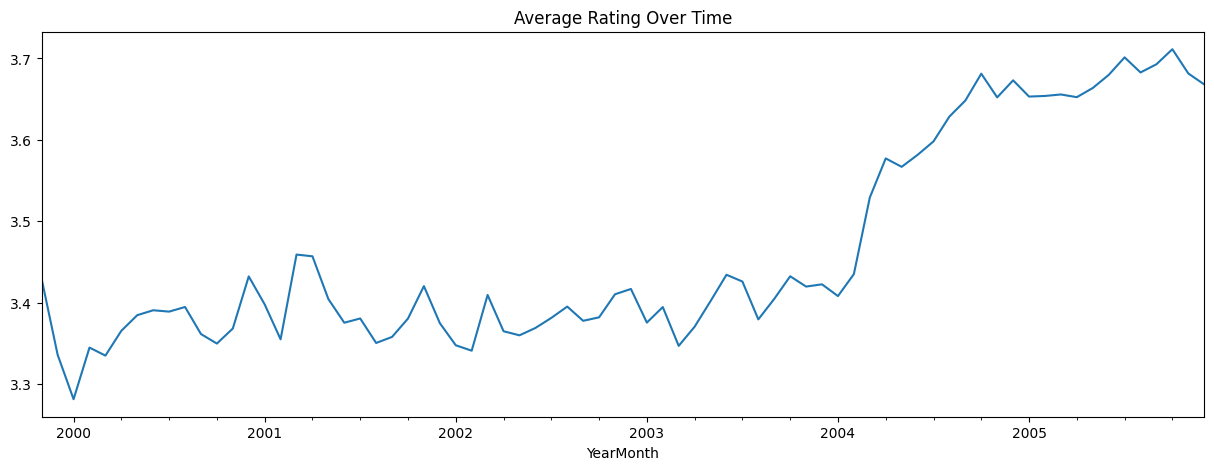

In [246]:
plt.figure(figsize=(15,5))

monthly_avg.plot()

plt.title(
    "Average Rating Over Time"
)
plt.savefig(
    "average_rating_over_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Long Tail Analysis

In [27]:
movie_popularity = (
    ratings_df["MovieID"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

In [28]:
# share of cumulative sum
cum_share = (
    movie_popularity.cumsum()
    /
    movie_popularity.sum()
)

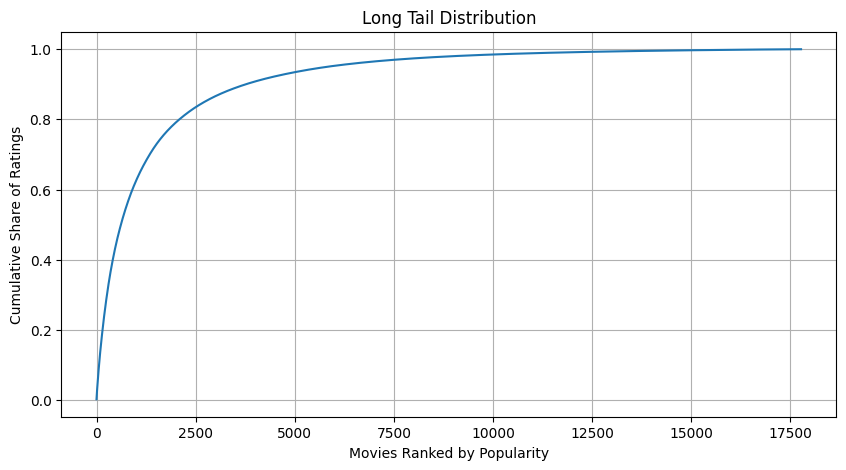

In [247]:
plt.figure(figsize=(10,5))

plt.plot(cum_share.values)

plt.xlabel(
    "Movies Ranked by Popularity"
)

plt.ylabel(
    "Cumulative Share of Ratings"
)

plt.title(
    "Long Tail Distribution"
)

plt.grid()
plt.savefig(
    "long_tail_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Sparsity and Density

In [30]:
n_users = ratings_df["UserID"].nunique()
n_movies = ratings_df["MovieID"].nunique()

possible_interactions = n_users * n_movies
actual_interactions = len(ratings_df)

density = actual_interactions / possible_interactions
sparsity = 1 - density

print(f"Users      : {n_users:,}")
print(f"Movies     : {n_movies:,}")
print(f"Ratings    : {actual_interactions:,}")

print(f"Density    : {density:.6f}")
print(f"Sparsity   : {sparsity:.6f}")

Users      : 480,189
Movies     : 17,770
Ratings    : 100,480,507
Density    : 0.011776
Sparsity   : 0.988224


| Metric | Value |
|---------|---------|
| Users | 480,189 |
| Movies | 17,770 |
| Ratings | 100,480,507 |
| Density | 1.18% |
| Sparsity | 98.82% |

# Train/Valid/Test Split

In [31]:
for threshold in [200, 300,400, 500]:
    
    users = user_counts[user_counts >= threshold]

    subset = ratings_df[
        ratings_df["UserID"].isin(users.index)
    ]

    print(f"\nThreshold = {threshold}")

    print(
        "Users:",
        subset["UserID"].nunique()
    )

    print(
        "Ratings:",
        len(subset)
    )


Threshold = 200
Users: 150850
Ratings: 77741622

Threshold = 300
Users: 103934
Ratings: 66240870

Threshold = 400
Users: 74509
Ratings: 56062826

Threshold = 500
Users: 54404
Ratings: 47092231


In [32]:
# dataset for collaborative filtering
cf_df = ratings_df[
    ratings_df["UserID"].isin(
        user_counts[user_counts >= 500].index
    )
].copy()

In [33]:
# shuffle and get user interaction count
cf_df = cf_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)
user_sizes = cf_df.groupby(
    "UserID"
).size()

In [34]:
# merge counts
cf_df["user_size"] = cf_df["UserID"].map(
    user_sizes
).astype("int32")

In [35]:
# position within user
cf_df["user_pos"] = (
    cf_df.groupby("UserID")
         .cumcount()
         .astype("int32")
)

In [36]:
train_cutoff = (
    cf_df["user_size"] * 0.80
).astype("int32")

valid_cutoff = (
    cf_df["user_size"] * 0.90
).astype("int32")
cf_df["Split"] = np.where(
    cf_df["user_pos"] < train_cutoff,
    "train",
    np.where(
        cf_df["user_pos"] < valid_cutoff,
        "valid",
        "test"
    )
)

In [37]:
train_df = cf_df[
    cf_df["Split"] == "train"
].drop(
    columns=[
        "user_size",
        "user_pos",
        "Split"
    ]
)

valid_df = cf_df[
    cf_df["Split"] == "valid"
].drop(
    columns=[
        "user_size",
        "user_pos",
        "Split"
    ]
)

test_df = cf_df[
    cf_df["Split"] == "test"
].drop(
    columns=[
        "user_size",
        "user_pos",
        "Split"
    ]
)

In [38]:
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

print()

print(len(train_df) /len(cf_df))

print(len(valid_df) /len(cf_df))

print(len(test_df) /len(cf_df))

Train: 37652046
Valid: 4706455
Test : 4733730

0.7995383782093484
0.09994121960371764
0.10052040218693398


In [39]:
del cf_df
gc.collect()

27052

# Baseline

In [40]:

def calculate_rmse(df, actual_col, pred_col, verbose=True):
    
    rmse = np.sqrt(
        mean_squared_error(
            df[actual_col],
            df[pred_col]
        )
    )

    if verbose:
        print(f"{pred_col} RMSE: {rmse:.4f}")

    return rmse

In [41]:
valid_sample = valid_df.sample(
    500_000,
    random_state=42
)

### 1. Global mean

In [42]:
global_mean = train_df[
    "Rating"
].mean()

print(global_mean)

valid_sample["pred_global"] = global_mean

3.519618747942675


In [43]:
rmse_global = calculate_rmse(
    valid_sample,
    actual_col="Rating",
    pred_col="pred_global"
)
print("Global Mean RMSE: ", rmse_global)

pred_global RMSE: 1.0725
Global Mean RMSE:  1.072487591608124


### 2. user mean

In [44]:
user_mean = (
    train_df
    .groupby("UserID")["Rating"]
    .mean()
)
valid_sample["pred_user"] = (
    valid_sample["UserID"]
    .map(user_mean)
)
valid_sample["pred_user"] = (
    valid_sample["pred_user"]
    .fillna(global_mean)
)

In [45]:
rmse_user_mean=calculate_rmse(valid_sample,actual_col="Rating",pred_col="pred_user")

pred_user RMSE: 0.9789


### 3. Movie mean

In [46]:
# get moviewise mean and fallback to global mean if NAN
movie_mean = (
    train_df
    .groupby("MovieID")["Rating"]
    .mean()
)
valid_sample["pred_movie"] = (
    valid_sample["MovieID"]
    .map(movie_mean)
)
valid_sample["pred_movie"] = (
    valid_sample["pred_movie"]
    .fillna(global_mean)
)

In [47]:
rmse_movie=calculate_rmse(valid_sample, actual_col="Rating",pred_col="pred_movie")

pred_movie RMSE: 0.9976


In [48]:
baseline_results = pd.DataFrame({
    "Model":[
        "Global Mean",
        "User Mean",
        "Movie Mean"
    ],
    "RMSE":[
        rmse_global,
        rmse_user_mean,
        rmse_movie
    ]
})

baseline_results

,Model,RMSE
0,Global Mean,1.072488
1,User Mean,0.978900
2,Movie Mean,0.997634


# User Based Collaborative Filtering

In [49]:
top_users = user_counts[
    user_counts >= 1000
].index

user_cf_df = train_df[
    train_df["UserID"].isin(top_users)
].copy()

print(
    "Users:",
    user_cf_df["UserID"].nunique()
)

print(
    "Ratings:",
    len(user_cf_df)
)

Users: 13141
Ratings: 15023753


### Creating user-item matrix

In [50]:
user_codes = pd.Categorical(
    user_cf_df["UserID"]
)

movie_codes = pd.Categorical(
    user_cf_df["MovieID"]
)

In [51]:
# csr matrix, it saves the space 
user_item_matrix = csr_matrix(
    (
        user_cf_df["Rating"].astype(np.float32),
        (
            user_codes.codes,
            movie_codes.codes
        )
    )
)

In [52]:
print("Shape :", user_item_matrix.shape)

print(
    "Non-zero entries:",
    user_item_matrix.nnz
)

Shape : (13141, 17770)
Non-zero entries: 15023753


In [53]:
n_users, n_movies = user_item_matrix.shape

density = (
    user_item_matrix.nnz
    /
    (n_users * n_movies)
)

print(
    f"Density: {density:.4f}"
)

print(
    f"Sparsity: {1-density:.4f}"
)

Density: 0.0643
Sparsity: 0.9357


### Cosine similarity b/w users

In [54]:
# cosine simliarti between users
user_similarity = cosine_similarity(
    user_item_matrix,
    dense_output=True
)

In [55]:
print(
    user_similarity.shape
)

print(
    user_similarity.min(),
    user_similarity.max()
)

(13141, 13141)
0.009961437 1.0000755


In [56]:
# mapping userID->matrix row and movieID->matrix_col
user_to_idx = {
    user: idx
    for idx, user in enumerate(
        user_codes.categories
    )
}

idx_to_user = {
    idx: user
    for user, idx in user_to_idx.items()
}
movie_to_idx = {
    movie: idx
    for idx, movie in enumerate(
        movie_codes.categories
    )
}

idx_to_movie = {
    idx: movie
    for movie, idx in movie_to_idx.items()
}

### Top K neighbors

In [57]:
K = 50
top_neighbors = np.argsort(
    -user_similarity,
    axis=1
)[:,1:K+1]

In [58]:
top_neighbors.shape

(13141, 50)

In [59]:
user_item_csr = user_item_matrix.tocsr()

### prediction function of rating

In [60]:
def predict_user_cf(
    user_id,
    movie_id
):
    
    if user_id not in user_to_idx:
        return global_mean

    if movie_id not in movie_to_idx:
        return global_mean

    u_idx = user_to_idx[user_id]
    m_idx = movie_to_idx[movie_id]

    neighbors = top_neighbors[u_idx]

    ratings = user_item_csr[
        neighbors,
        m_idx
    ].toarray().flatten()

    sims = user_similarity[
        u_idx,
        neighbors
    ]

    mask = ratings > 0

    if mask.sum() == 0:
        return global_mean

    return np.dot(
        ratings[mask],
        sims[mask]
    ) / np.sum(
        sims[mask]
    )

In [61]:
eval_sample = valid_df.sample(
    10000,
    random_state=42
)
preds = []

for row in eval_sample.itertuples():

    preds.append(
        predict_user_cf(
            row.UserID,
            row.MovieID
        )
    )

In [62]:
eval_sample = eval_sample.copy()

eval_sample[
    "pred_user_cf"
] = preds

In [63]:
rmse_user_cf = calculate_rmse(eval_sample,actual_col="Rating",pred_col="pred_user_cf")
print(
    "User-CF RMSE:",
    rmse_user_cf
)

pred_user_cf RMSE: 1.0340
User-CF RMSE: 1.0339501801403144


# Item-Based Collaborative Filtering

In [64]:
# it is user*movie , transpose it bcz we need movei*user
item_user_matrix = user_item_matrix.T

In [65]:
print(item_user_matrix.shape)

(17770, 13141)


In [66]:
item_similarity = cosine_similarity(
    item_user_matrix,
    dense_output=True
)

In [67]:
print(item_similarity.shape)

print(
    f'{item_similarity.min():.4F}  '
    f'{item_similarity.max():.4F}'
)

(17770, 17770)
0.0000  1.0001


In [68]:
# map MovieID to matrix position for fast retrival
movie_to_idx = {
    movie: idx
    for idx, movie in enumerate(
        movie_codes.categories
    )
}
idx_to_movie = {
    idx: movie
    for movie, idx in movie_to_idx.items()
}

In [69]:
K = 50
top_item_neighbors = np.argsort(
    -item_similarity,
    axis=1
)[:,1:K+1]
top_item_neighbors.shape

(17770, 50)

In [70]:
# lookup table to know user rated which movies
user_history = (
    user_cf_df
    .groupby("UserID")
    .apply(
        lambda x: list(
            zip(
                x["MovieID"],
                x["Rating"]
            )
        )
    )
    .to_dict()
)



/tmp/ipykernel_82/4156444423.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [71]:
sample_user = next(
    iter(user_history)
)

print(sample_user)

print(len(user_history[sample_user]))

769
903


### prediction function for rating

In [72]:
def predict_item_cf(
    user_id,
    movie_id,
    k=50
):

    if user_id not in user_history:
        return global_mean

    if movie_id not in movie_to_idx:
        return global_mean

    target_idx = movie_to_idx[movie_id]

    rated_movies = user_history[user_id]

    similarities = []

    ratings = []

    for rated_movie, rating in rated_movies:

        if rated_movie == movie_id:
            continue

        if rated_movie not in movie_to_idx:
            continue

        sim = item_similarity[
            target_idx,
            movie_to_idx[rated_movie]
        ]

        if sim > 0:

            similarities.append(sim)
            ratings.append(rating)

    if len(similarities) == 0:
        return global_mean

    similarities = np.array(similarities)
    ratings = np.array(ratings)

    top_idx = np.argsort(
        similarities
    )[-k:]

    similarities = similarities[top_idx]
    ratings = ratings[top_idx]

    return np.dot(
        similarities,
        ratings
    ) / similarities.sum()

In [73]:
eval_sample = valid_df.sample(
    10000,
    random_state=42
)

In [74]:
preds_item = []

for row in eval_sample.itertuples():

    preds_item.append(
        predict_item_cf(
            row.UserID,
            row.MovieID
        )
    )

eval_sample = eval_sample.copy()

eval_sample[
    "pred_item_cf"
] = preds_item

In [75]:
rmse_item_cf=calculate_rmse(eval_sample,"Rating","pred_item_cf")
print(
    "Item-CF RMSE:",
    rmse_item_cf
)

pred_item_cf RMSE: 1.0137
Item-CF RMSE: 1.0137482386507402


# Bias-Aware Matrix Factorization with SGD

In [76]:
mf_source = train_df.copy()
# ms_source=cf_df.copy()

In [187]:
mf_source.shape

(37652046, 5)

In [188]:
# mapping of user to its idx and same for movie
user_ids = mf_source["UserID"].unique()
movie_ids = mf_source["MovieID"].unique()

user_to_idx = {
    u:i
    for i,u in enumerate(user_ids)
}

movie_to_idx = {
    m:i
    for i,m in enumerate(movie_ids)
}

In [189]:
#kkep only those column
mf_data = mf_source[
    ["UserID","MovieID","Rating"]
].copy()

mf_data["u"] = mf_data["UserID"].map(
    user_to_idx
)

mf_data["i"] = mf_data["MovieID"].map(
    movie_to_idx
)

In [190]:
n_users = len(user_to_idx)
n_items = len(movie_to_idx)

print(n_users)
print(n_items)
print(len(mf_data))

54404
17770
37652046


In [191]:
# convert to numpy arrays for faster training
users_np = mf_data["u"].values.astype(np.int32)

items_np = mf_data["i"].values.astype(np.int32)

ratings_np = mf_data["Rating"].values.astype(
    np.float32
)

In [192]:
# initialize parameters for SGD Model
rng = np.random.default_rng(42)
k=50
P = rng.normal(
    0,
    0.1,
    size=(n_users, k)
).astype(np.float32)

Q = rng.normal(
    0,
    0.1,
    size=(n_items, k)
).astype(np.float32)
bu = np.zeros(
    n_users,
    dtype=np.float32
)

bi = np.zeros(
    n_items,
    dtype=np.float32
)

In [193]:
# sample_size = 10_000_000
# sample_idx = np.random.choice(
#     len(ratings_np),
#     size=sample_size,
#     replace=False
# )

sample_idx = np.arange(len(ratings_np))

In [194]:
print("ratings:", len(ratings_np))
print("users:", len(np.unique(users_np)))
print("items:", len(np.unique(items_np)))

ratings: 37652046
users: 54404
items: 17770


In [195]:
print(P.shape)
print(Q.shape)
print(users_np.min(), users_np.max())
print(items_np.min(), items_np.max())
print(ratings_np.dtype)
print(ratings_np.min())
print(ratings_np.max())

(54404, 50)
(17770, 50)
0 54403
0 17769
float32
1.0
5.0


In [196]:
print(train_df.columns)
print(valid_df.columns)
print(test_df.columns)

Index(['UserID', 'MovieID', 'Rating', 'Date', 'YearMonth', 'u', 'i'], dtype='object')
Index(['UserID', 'MovieID', 'Rating', 'Date', 'YearMonth', 'u', 'i'], dtype='object')
Index(['UserID', 'MovieID', 'Rating', 'Date', 'YearMonth', 'u', 'i'], dtype='object')


In [197]:
# print(global_mean)
# print(train_df["Rating"].mean())
print("train:", len(train_df))
print("valid:", len(valid_df))
print("test :", len(test_df))

train: 37652046
valid: 4706455
test : 4733730


In [198]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [199]:
train_df["u"] = train_df["UserID"].map(user_to_idx)
train_df["i"] = train_df["MovieID"].map(movie_to_idx)

valid_df["u"] = valid_df["UserID"].map(user_to_idx)
valid_df["i"] = valid_df["MovieID"].map(movie_to_idx)

test_df["u"] = test_df["UserID"].map(user_to_idx)
test_df["i"] = test_df["MovieID"].map(movie_to_idx)

In [200]:
print(train_df[["u","i"]].isna().sum())
print(valid_df[["u","i"]].isna().sum())
print(test_df[["u","i"]].isna().sum())

u    0
i    0
dtype: int64
u    0
i    0
dtype: int64
u    0
i    0
dtype: int64


In [201]:
print("n_users =", len(user_to_idx))
print("n_items =", len(movie_to_idx))

n_users = 54404
n_items = 17770


In [202]:

from torch.utils.data import Dataset

In [203]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = df["u"].values.astype(np.int64)
        self.items = df["i"].values.astype(np.int64)
        self.ratings = df["Rating"].values.astype(np.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.items[idx],
            self.ratings[idx]
        )

In [204]:
from torch.utils.data import DataLoader
batch_size = 262144
train_ds = RatingsDataset(train_df)
valid_ds = RatingsDataset(valid_df)
test_ds  = RatingsDataset(test_df)

In [205]:
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [206]:
import torch.nn as nn
class MatrixFactorization(nn.Module):

    def __init__(
        self,
        n_users,
        n_items,
        k,
        global_mean
    ):
        super().__init__()

        self.user_factors = nn.Embedding(
            n_users,
            k
        )

        self.item_factors = nn.Embedding(
            n_items,
            k
        )

        self.user_bias = nn.Embedding(
            n_users,
            1
        )

        self.item_bias = nn.Embedding(
            n_items,
            1
        )

        self.global_mean = global_mean

        nn.init.normal_(
            self.user_factors.weight,
            std=0.1
        )

        nn.init.normal_(
            self.item_factors.weight,
            std=0.1
        )

        nn.init.zeros_(
            self.user_bias.weight
        )

        nn.init.zeros_(
            self.item_bias.weight
        )

    def forward(
        self,
        users,
        items
    ):

        pu = self.user_factors(users)
        qi = self.item_factors(items)

        dot = (pu * qi).sum(dim=1)

        bu = self.user_bias(users).squeeze()
        bi = self.item_bias(items).squeeze()

        pred = (
            self.global_mean
            + bu
            + bi
            + dot
        )

        return pred

In [207]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [208]:
k = 64
model = MatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    k=k,
    global_mean=float(train_df["Rating"].mean())
)
model = model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [209]:
@torch.no_grad()
def evaluate_rmse(
    model,
    loader,
    device
):
    model.eval()

    sse = 0.0
    n = 0

    for users, items, ratings in loader:

        users = users.to(
            device,
            non_blocking=True
        )

        items = items.to(
            device,
            non_blocking=True
        )

        ratings = ratings.to(
            device,
            non_blocking=True
        )

        pred = model(
            users,
            items
        )

        sse += (
            (pred - ratings) ** 2
        ).sum().item()

        n += len(ratings)

    return np.sqrt(sse / n)

In [210]:
best_rmse = float("inf")
patience = 2
bad_epochs = 0

epochs = 15

In [211]:
for epoch in range(epochs):

    model.train()

    train_sse = 0.0
    train_n = 0

    for users, items, ratings in train_loader:

        users = users.to(
            device,
            non_blocking=True
        )

        items = items.to(
            device,
            non_blocking=True
        )

        ratings = ratings.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        pred = model(
            users,
            items
        )

        loss = (
            (pred - ratings) ** 2
        ).mean()

        loss.backward()

        optimizer.step()

        train_sse += (
            (pred - ratings) ** 2
        ).sum().item()

        train_n += len(ratings)

    train_rmse = np.sqrt(
        train_sse / train_n
    )

    valid_rmse = evaluate_rmse(
        model,
        valid_loader,
        device
    )

    print(
        f"Epoch {epoch+1} | "
        f"Train RMSE={train_rmse:.4f} | "
        f"Valid RMSE={valid_rmse:.4f}"
    )

    if valid_rmse < best_rmse:

        best_rmse = valid_rmse

        torch.save(
            model.state_dict(),
            "best_mf.pt"
        )

        bad_epochs = 0

    else:
        bad_epochs += 1

        if bad_epochs >= patience:

            print("Early stopping")
            break

Epoch 1 | Train RMSE=1.0469 | Valid RMSE=1.0196
Epoch 2 | Train RMSE=0.9913 | Valid RMSE=0.9661
Epoch 3 | Train RMSE=0.9234 | Valid RMSE=0.8984
Epoch 4 | Train RMSE=0.8715 | Valid RMSE=0.8674
Epoch 5 | Train RMSE=0.8442 | Valid RMSE=0.8491
Epoch 6 | Train RMSE=0.8252 | Valid RMSE=0.8365
Epoch 7 | Train RMSE=0.8104 | Valid RMSE=0.8275
Epoch 8 | Train RMSE=0.7986 | Valid RMSE=0.8211
Epoch 9 | Train RMSE=0.7888 | Valid RMSE=0.8164
Epoch 10 | Train RMSE=0.7805 | Valid RMSE=0.8129
Epoch 11 | Train RMSE=0.7732 | Valid RMSE=0.8102
Epoch 12 | Train RMSE=0.7668 | Valid RMSE=0.8082
Epoch 13 | Train RMSE=0.7610 | Valid RMSE=0.8067
Epoch 14 | Train RMSE=0.7559 | Valid RMSE=0.8055
Epoch 15 | Train RMSE=0.7513 | Valid RMSE=0.8046


In [213]:
model.load_state_dict(
    torch.load("best_mf.pt")
)

<All keys matched successfully>

In [214]:
test_rmse = evaluate_rmse(
    model,
    test_loader,
    device
)

print(
    f"Test RMSE = {test_rmse:.4f}"
)

Test RMSE = 0.8048


# Recommendation Pipeline

In [215]:
# extracting weights
with torch.no_grad():

    user_emb = (
        model.user_factors.weight
        .detach()
    )

    item_emb = (
        model.item_factors.weight
        .detach()
    )

    user_bias = (
        model.user_bias.weight
        .detach()
        .squeeze()
    )

    item_bias = (
        model.item_bias.weight
        .detach()
        .squeeze()
    )

In [216]:
# the movies users have already seen won't be included in recommendation
user_seen_movies = (
    train_df
    .groupby("UserID")["MovieID"]
    .apply(set)
    .to_dict()
)


In [217]:
# mapping idx ot movie
idx_to_movie = {
    idx: movie
    for movie, idx
    in movie_to_idx.items()
}

In [127]:
# all_movie_ids = np.array(
#     list(movie_to_idx.keys())
# )

# all_movie_indices = np.array(
#     [movie_to_idx[m] for m in all_movie_ids]
# )

In [218]:
# function to recommend top_k movies
def recommend_mf_torch(
    user_id,
    top_k=10
):

    if user_id not in user_to_idx:
        return []

    u_idx = user_to_idx[user_id]

    with torch.no_grad():

        scores = (
            model.global_mean
            + user_bias[u_idx]
            + item_bias
            + torch.matmul(
                item_emb,
                user_emb[u_idx]
            )
        )

    scores = scores.cpu()

    seen = user_seen_movies.get(
        user_id,
        set()
    )

    if len(seen) > 0:

        seen_idx = [
            movie_to_idx[m]
            for m in seen
            if m in movie_to_idx
        ]

        scores[seen_idx] = -1e9

    top_scores, top_indices = torch.topk(
        scores,
        k=top_k
    )

    results = []

    for idx, score in zip(
        top_indices.tolist(),
        top_scores.tolist()
    ):

        results.append(
            (
                idx_to_movie[idx],
                score
            )
        )

    return results

In [222]:
# relevant items where rating >=3.5
relevant_items = (
    test_df[
        test_df["Rating"] >= 3.5
    ]
    .groupby("UserID")["MovieID"]
    .apply(set)
    .to_dict()
)

In [223]:
# AP@10  Function
def average_precision_at_k(
    actual,
    predicted,
    k=10
):

    predicted = predicted[:k]

    hits = 0
    score = 0

    for i, item in enumerate(
        predicted,
        start=1
    ):

        if item in actual:

            hits += 1
            score += hits / i

    if len(actual) == 0:
        return 0

    return score / min(
        len(actual),
        k
    )

In [224]:
import random
candidate_users = list(
    relevant_items.keys()
)

In [238]:
len(candidate_users)

54390

In [239]:
eval_users = random.sample(
    candidate_users,
    54390
)
ap_scores = []
for user_id in eval_users:

    actual = relevant_items[user_id]

    recs = recommend_mf_torch(
        user_id,
        top_k=10
    )

    predicted = [
        movie_id
        for movie_id, _
        in recs
    ]

    ap = average_precision_at_k(
        actual,
        predicted,
        k=10
    )

    ap_scores.append(ap)

In [240]:
map10_mf = np.mean(
    ap_scores
)

print(
    "MF MAP@10:",
    map10_mf
)

MF MAP@10: 0.049652070171425526


In [227]:
print(model.user_factors.weight.shape)
model.item_factors.weight.shape

torch.Size([54404, 64])


torch.Size([17770, 64])

# Recommendation examples

In [260]:
active_users = (
    train_df
    .groupby("UserID")
    .size()
    .sort_values(ascending=False)
)

sample_users = active_users.index[
    [100, 2, 602]
]

In [261]:
def show_recommendation_case(
    user_id,
    top_history=5,
    top_rec=5
):

    print("="*80)
    print(f"USER: {user_id}")

    history = (
        train_df[
            (train_df["UserID"] == user_id)
            &
            (train_df["Rating"] >= 4)
        ]
        .merge(
            movies,
            on="MovieID"
        )
        [["Title","Rating"]]
        .head(top_history)
    )

    print("\nLiked Movies")
    display(history)

    recs = recommend_mf_torch(
        user_id,
        top_k=top_rec
    )

    rec_df = pd.DataFrame(
        recs,
        columns=[
            "MovieID",
            "PredictedScore"
        ]
    )

    rec_df = rec_df.merge(
        movies,
        on="MovieID",
        how="left"
    )

    print("\nRecommendations")

    display(
        rec_df[
            [
                "Title",
                "PredictedScore"
            ]
        ]
    )

In [262]:
for user_id in sample_users:
    show_recommendation_case(user_id)

USER: 71594

Liked Movies


,Title,Rating
0,Streets of Fire,4
1,Amadeus,5
2,Dangerous Liaisons,5
3,Moonlighting: The Pilot,4
4,The Ninth Gate,4



Recommendations


,Title,PredictedScore
0,Independence Day,4.808633
1,The Silence of the Lambs,4.696412
2,Pretty Woman,4.632873
3,Lord of the Rings: The Fellowship of the Ring:...,4.544178
4,The Green Mile,4.541388


USER: 2439493

Liked Movies


...

,Title,PredictedScore
0,The God Who Wasn't There,4.345243
1,The Wizard of Oz: Collector's Edition,4.224454
2,The Lord of the Rings: The Fellowship of the R...,4.199514
3,Lost: Season 1,4.145424
4,The Notebook,4.043060


USER: 567705

Liked Movies


,Title,Rating
0,Buffy the Vampire Slayer: The Movie,4
1,The Pretender: Season 1,4
2,Inspector Gadget,4
3,Hellboy,4
4,Behind the Planet of the Apes,4



Recommendations


,Title,PredictedScore
0,The Twilight Zone: Vol. 14,4.972330
1,The Twilight Zone: Vol. 15,4.935064
2,The Twilight Zone: Vol. 18,4.916762
3,The Twilight Zone: Vol. 27,4.901951
4,The Twilight Zone: Vol. 9,4.901513


## Coverage Metric

In [231]:
sample_users = (
    train_df["UserID"]
    .drop_duplicates()
    .sample(
        1000,
        random_state=42
    )
)

In [232]:
recommended_movies = set()

for user_id in sample_users:

    recs = recommend_mf_torch(
        user_id,
        top_k=10
    )

    for movie_id, _ in recs:

        recommended_movies.add(
            movie_id
        )

In [233]:
coverage = (
    len(recommended_movies)
    /
    movies["MovieID"].nunique()
)

print(
    f"Coverage: {coverage:.4f}"
)

Coverage: 0.0945


## Checking popularity bias in prediction

In [234]:
movie_popularity = (
    train_df
    .groupby("MovieID")
    .size()
    .reset_index(
        name="RatingCount"
    )
)
popular_movies = (
    movie_popularity
    .merge(
        movies,
        on="MovieID"
    )
    .sort_values(
        "RatingCount",
        ascending=False
    )
)

In [235]:
popular_movies[
    [
        "Title",
        "RatingCount"
    ]
].head(10)

,Title,RatingCount
1904,Pirates of the Caribbean: The Curse of the Bla...,39744
11282,Forrest Gump,39238
4305,The Sixth Sense,38651
15123,Independence Day,38479
15106,Ocean's Eleven,38435
14690,The Matrix,38276
14409,Spider-Man,37831
2451,Lord of the Rings: The Fellowship of the Ring,37335
13727,Gladiator,37262
2861,The Silence of the Lambs,37215


In [236]:
# recommend movie popularity
recommended_popularity = (
    movie_popularity[
        movie_popularity["MovieID"]
        .isin(
            recommended_movies
        )
    ]
)
print(
    "Average Popularity of Recommended Movies:"
)

print(
    recommended_popularity[
        "RatingCount"
    ].mean()
)
print(
    "Average Popularity of All Movies:"
)

print(
    movie_popularity[
        "RatingCount"
    ].mean()
)

Average Popularity of Recommended Movies:
8081.1661703394875
Average Popularity of All Movies:
2118.854586381542
